# Liver Disease Prediction Model — Random Forest
Dataset: Indian Liver Patient Dataset (OpenML ilpd)
Task: Binary classification

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import shap
import joblib
import os
MODEL_DIR = '../models'
os.makedirs(MODEL_DIR, exist_ok=True)
print('Setup complete')

Setup complete


In [5]:
data = fetch_openml('ilpd', version=1, as_frame=True, parser='auto')
df = data.data.copy()
print('Feature columns:', df.columns.tolist())
print('Target name:', data.target.name)
print('Target unique values:', data.target.unique())
print('Shape:', df.shape)
df.head()

Feature columns: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10']
Target name: Class
Target unique values: ['1', '2']
Categories (2, str): ['1', '2']
Shape: (583, 10)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40


In [6]:
# Target: '1' = liver disease, '2' = no disease
df['target'] = (data.target.astype(str).str.strip() == '1').astype(int)
print('Class distribution:')
print(df['target'].value_counts())

# Encode categorical columns (e.g. Gender / V2)
# Must cast to object first — fetch_openml returns Categorical dtype which
# rejects .loc assignment of new integer codes
for col in df.select_dtypes(include=['category', 'object']).columns:
    df[col] = df[col].astype(object)          # strip Categorical dtype
    le = LabelEncoder()
    mask = df[col].notna()
    df.loc[mask, col] = le.fit_transform(df.loc[mask, col].astype(str))
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.fillna(df.median(numeric_only=True))

feature_names = [c for c in df.columns if c != 'target']
X = df[feature_names].astype(float).values
y = df['target'].values
print('Features:', feature_names)
print('Class distribution:', np.bincount(y))

Class distribution:
target
1    416
0    167
Name: count, dtype: int64
Features: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10']
Class distribution: [167 416]


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 466 | Test: 117


In [8]:
model = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_split=5,
    min_samples_leaf=2, class_weight='balanced',
    random_state=42, n_jobs=-1
)
model.fit(X_train, y_train)
print('Training complete')

Training complete


In [9]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Liver Disease']))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='roc_auc')
print(f'5-Fold CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')

Accuracy : 0.7436
ROC-AUC  : 0.8037

               precision    recall  f1-score   support

      Healthy       0.55      0.71      0.62        34
Liver Disease       0.86      0.76      0.81        83

     accuracy                           0.74       117
    macro avg       0.70      0.73      0.71       117
 weighted avg       0.77      0.74      0.75       117

5-Fold CV ROC-AUC: 0.7541 (+/- 0.0251)


<Figure size 800x500 with 0 Axes>

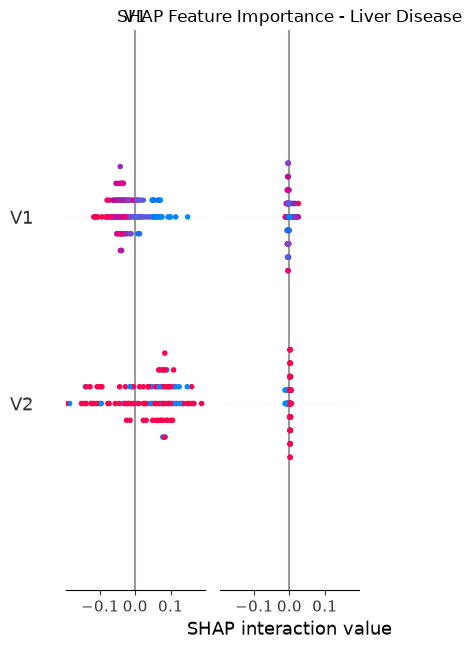

SHAP plot saved


In [10]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values
plt.figure(figsize=(8, 5))
shap.summary_plot(sv, X_test, feature_names=feature_names, show=False)
plt.title('SHAP Feature Importance - Liver Disease')
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/liver_shap.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP plot saved')

In [11]:
joblib.dump(model,         f'{MODEL_DIR}/liver_model.pkl')
joblib.dump(scaler,        f'{MODEL_DIR}/liver_scaler.pkl')
joblib.dump(feature_names, f'{MODEL_DIR}/liver_features.pkl')
for fname in ['liver_model.pkl', 'liver_scaler.pkl', 'liver_features.pkl']:
    size = os.path.getsize(f'{MODEL_DIR}/{fname}') / 1024
    print(f'  {fname}  ({size:.1f} KB)')
print('All liver artifacts saved!')

  liver_model.pkl  (2006.7 KB)
  liver_scaler.pkl  (0.8 KB)
  liver_features.pkl  (0.1 KB)
All liver artifacts saved!
